# Village-Level Water Quality Analysis

This notebook replicates the water quality analysis from `water_quality_analysis.ipynb`, but aggregated at the **village level** rather than the pond level.

Steps:
1. Infer village names for ponds using coordinate proximity (Haversine distance).
2. Merge with water quality data.
3. Aggregate measurements by `inferred_village` and `Date` to handle multiple pond measurements in a single village on the same day.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

# Load Datasets
df_wq = pd.read_csv('data/water_quality.csv')
df_loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# Clean Location Data
df_loc_clean = df_loc[['public_pond_id', 'region', 'village', 'latitude', 'longitude']].copy()
df_loc_clean['latitude'] = pd.to_numeric(df_loc_clean['latitude'], errors='coerce')
df_loc_clean['longitude'] = pd.to_numeric(df_loc_clean['longitude'], errors='coerce')
df_loc_clean['has_coords'] = df_loc_clean['latitude'].notna() & df_loc_clean['longitude'].notna()
df_loc_clean['has_village'] = df_loc_clean['village'].notna() & df_loc_clean['village'].astype(str).str.strip().ne('')

# Reference ponds (with village and coords)
ref_ponds = df_loc_clean[df_loc_clean['has_coords'] & df_loc_clean['has_village']].copy()

def infer_village(row):
    if row['has_village']:
        return row['village']
    if not row['has_coords']:
        return None
    
    min_dist = float('inf')
    best_village = None
    
    for _, ref in ref_ponds.iterrows():
        d = haversine_km(row['latitude'], row['longitude'], ref['latitude'], ref['longitude'])
        if d < min_dist:
            min_dist = d
            best_village = ref['village']
    return best_village

df_loc_clean['inferred_village'] = df_loc_clean.apply(infer_village, axis=1)
df_loc_clean['location_status'] = df_loc_clean.apply(
    lambda r: 'Has Location' if (r['has_coords'] or r['has_village']) else 'No Location', axis=1
)

# Rename columns in WQ data to standard names
df_wq = df_wq.rename(columns={
    'Date of data collection': 'Date',
    'Time of data collection': 'Time',
    'DO (mg/L)': 'DO',
    'Temp (in °C)': 'Water Temperature'
})
df_wq['Date'] = pd.to_datetime(df_wq['Date'])

# Merge WQ with Inferred Locations
df_merged = df_wq.merge(df_loc_clean[['public_pond_id', 'inferred_village', 'location_status', 'region']], 
                        left_on='pond_id', right_on='public_pond_id', how='left')

# Filter for ponds with location
df_clean = df_merged[df_merged['location_status'] == 'Has Location'].drop(columns=['public_pond_id', 'location_status'])

print(f"Total observations with location (known or inferred): {len(df_clean)}")

Total observations with location (known or inferred): 9932


In [2]:
df_clean.columns

Index(['Sr. No', 'Date', 'Time', 'pond_id', 'region_x', 'Type', 'Is follow up',
       'Is follow up possible', 'Reason follow up not possible', 'Group',
       'Pond status', 'Observer', 'Equipment', 'Weather', 'DO', 'pH',
       'Turbidity (in cm)', 'Ammonia—TAN (NH3-N) (mg/L)',
       'Ammonia—TAN (NH3) (mg/L)', 'Ammonia—NH3 (mg/L)', 'Water Temperature',
       'TDS (ppt)', 'Alkalinity (mg/L)', 'Hardness (mg/L)', 'Water color',
       'Is WQ in range?', 'Parameters out of range',
       'Corrective actions requested', 'Corrective actions requested (other)',
       'Corrective actions amount requested', 'Corrective actions',
       'Corrective actions implemented',
       'Corrective actions implementation date', 'Corrective actions taken',
       'Corrective actions taken (other)',
       'Corrective actions taken (details)',
       'Non-prescribed corrective actions taken', 'Reason not implemented',
       'Water quality improved after corrective actions',
       'Corrective action

## Data Aggregation to Village Level

We aggregate pond-level measurements into a single village-level daily summary. This accounts for multiple ponds being measured in the same village on the same day.

In [3]:
# Aggregation logic to Village Level
# We aggregate pond-level measurements into a single village-level daily summary.
# This accounts for multiple ponds being measured in the same village on the same day.

# Ensure Date is datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Define aggregation stats for DO as requested
# We include 'region' in the groupby to preserve it (assuming 1 village per region)
# We also include 'Type' (Morning/Evening)
df_village = df_clean.groupby(['inferred_village', 'Date', 'region_x', 'Type']).agg(
    n_ponds=('pond_id', 'nunique'),
    highest_DO=('DO', 'max'),
    lowest_DO=('DO', 'min'),
    median_DO=('DO', 'median'),
    low_quartile_DO=('DO', lambda x: x.quantile(0.25)),
    high_quartile_DO=('DO', lambda x: x.quantile(0.75)),
    average_DO=('DO', 'mean'),
    average_pH=('pH', 'mean'),
    average_temp=('Water Temperature', 'mean')
).reset_index()

# Filter for Morning data as primarily used in the original analysis
morning_village = df_village[df_village['Type'] == 'Morning'].copy()
morning_village = morning_village.sort_values(['inferred_village', 'Date'])

print(f"Total village-level morning observations: {len(morning_village)}")
morning_village.head()

Total village-level morning observations: 2318


,inferred_village,Date,region_x,Type,n_ponds,highest_DO,lowest_DO,median_DO,low_quartile_DO,high_quartile_DO,average_DO,average_pH,average_temp
1,Aamuluru,2023-09-12,Nellore,Morning,5,4.1,3.3,3.5,3.4,3.8,3.62,8.040,29.28
3,Aamuluru,2023-10-12,Nellore,Morning,5,4.2,2.1,3.8,3.3,3.9,3.46,8.256,31.50
5,Aamuluru,2023-10-14,Nellore,Morning,1,2.5,2.5,2.5,2.5,2.5,2.50,8.230,31.10
7,Aamuluru,2023-11-17,Nellore,Morning,5,4.6,3.4,3.6,3.5,4.0,3.82,8.106,29.92
9,Aamuluru,2023-12-11,Nellore,Morning,5,4.1,2.6,3.3,3.3,3.5,3.36,8.058,31.34


## Analysis 1 — Distribution of Inter-Measurement Gaps (Village Level)

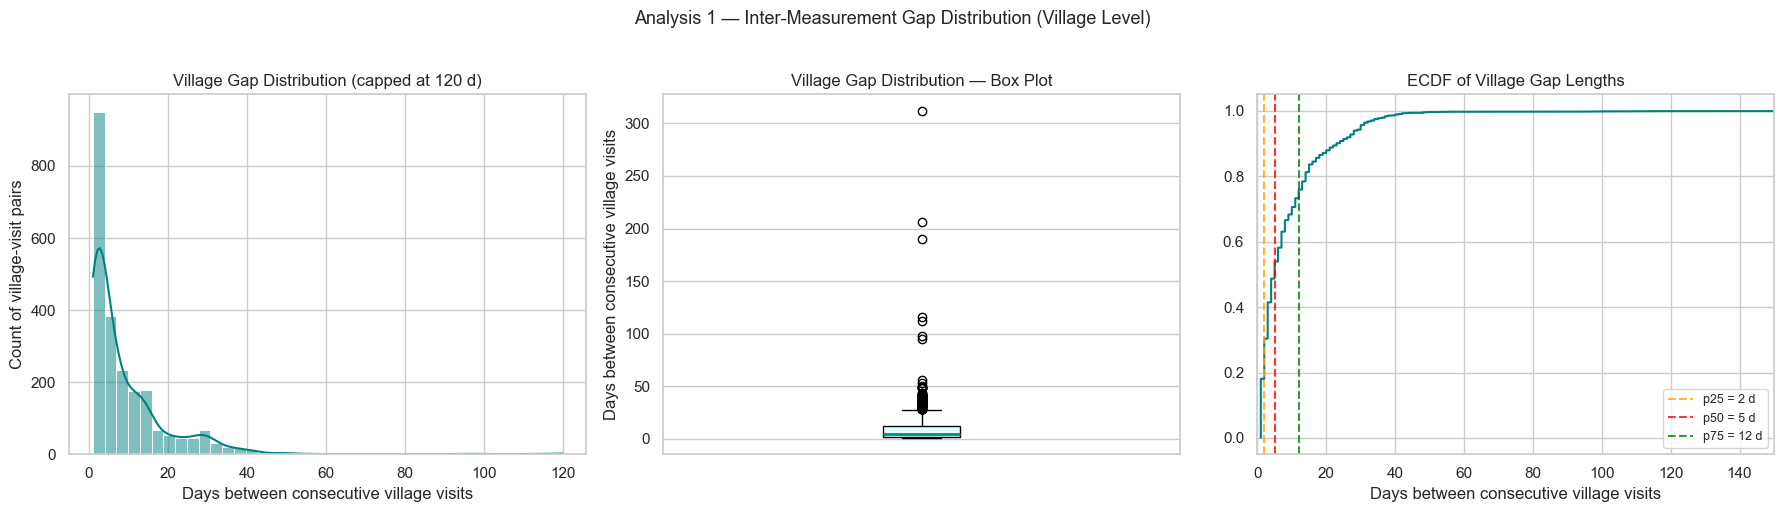

In [4]:
# Compute gaps between consecutive village visits
morning_village['gap_days'] = morning_village.groupby('inferred_village')['Date'].diff().dt.days

gaps_v = morning_village.dropna(subset=['gap_days'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
cap = 120
data_plot = gaps_v['gap_days'].clip(upper=cap)
ax = axes[0]
sns.histplot(data_plot, bins=40, kde=True, color='teal', ax=ax)
ax.set_title('Village Gap Distribution (capped at 120 d)')
ax.set_xlabel('Days between consecutive village visits')
ax.set_ylabel('Count of village-visit pairs')

# Box Plot
ax = axes[1]
ax.boxplot(gaps_v['gap_days'], vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightcyan'),
           medianprops=dict(color='darkcyan', linewidth=2))
ax.set_title('Village Gap Distribution — Box Plot')
ax.set_ylabel('Days between consecutive village visits')
ax.set_xticks([])

# ECDF
ax = axes[2]
sorted_gaps = np.sort(gaps_v['gap_days'])
ecdf_y = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)
ax.plot(sorted_gaps, ecdf_y, color='teal')
ax.set_xlim(0, 150)
for p, c in [(0.25, 'orange'), (0.50, 'red'), (0.75, 'green')]:
    v = np.percentile(sorted_gaps, p * 100)
    ax.axvline(v, color=c, linestyle='--', alpha=0.8, label=f'p{int(p*100)} = {v:.0f} d')
ax.legend(fontsize=9)
ax.set_title('ECDF of Village Gap Lengths')
ax.set_xlabel('Days between consecutive village visits')

plt.suptitle('Analysis 1 — Inter-Measurement Gap Distribution (Village Level)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 2 — Gap Interval Categories (Village Level)

/var/folders/1c/f0j4ygyd0jb136rvzr4n3sp00000gp/T/ipykernel_57129/2767262832.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')


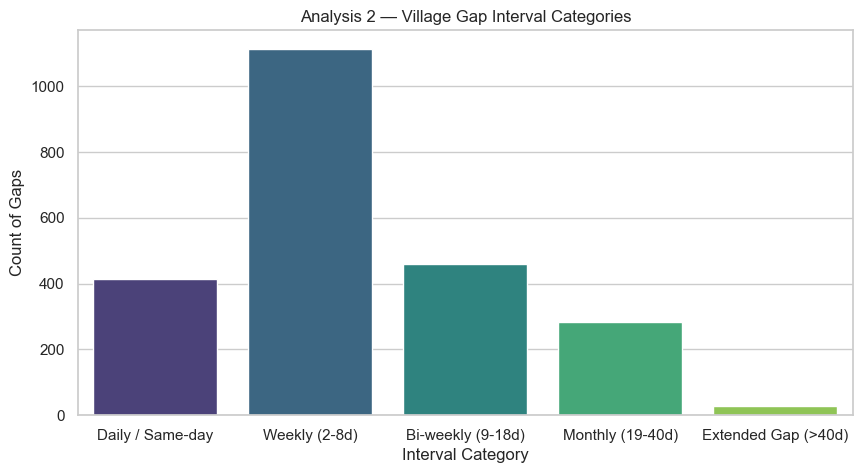

In [5]:
def categorize_gap(d):
    if d <= 1: return 'Daily / Same-day'
    if d <= 8: return 'Weekly (2-8d)'
    if d <= 18: return 'Bi-weekly (9-18d)'
    if d <= 40: return 'Monthly (19-40d)'
    return 'Extended Gap (>40d)'

gaps_v['category'] = gaps_v['gap_days'].apply(categorize_gap)
cat_counts = gaps_v['category'].value_counts().reindex([
    'Daily / Same-day', 'Weekly (2-8d)', 'Bi-weekly (9-18d)', 'Monthly (19-40d)', 'Extended Gap (>40d)'
]).fillna(0)

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='viridis')
plt.title('Analysis 2 — Village Gap Interval Categories')
plt.ylabel('Count of Gaps')
plt.xlabel('Interval Category')
plt.show()

## Analysis 3 — Observation Frequency by Month (Village Level)

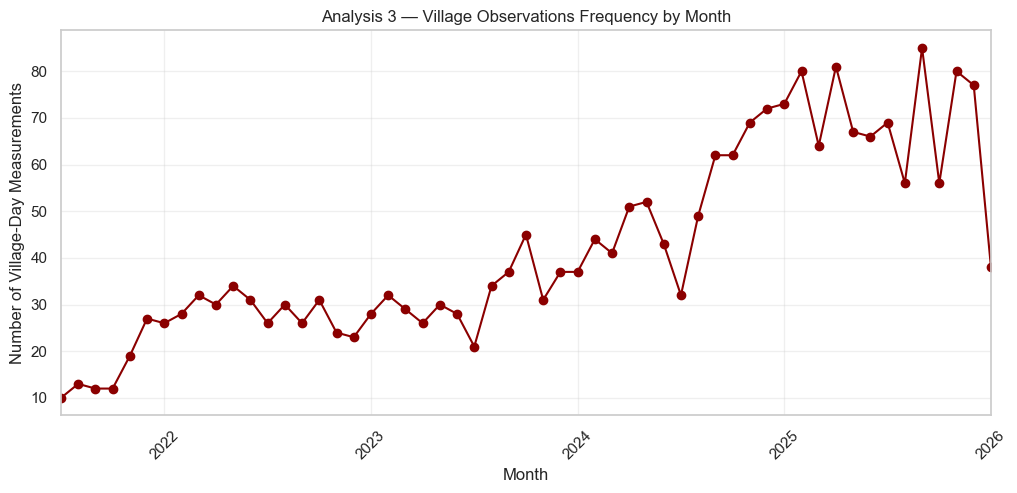

In [6]:
morning_village['Month'] = morning_village['Date'].dt.to_period('M')
monthly_obs = morning_village.groupby('Month').size()

plt.figure(figsize=(12, 5))
monthly_obs.plot(kind='line', marker='o', color='darkred')
plt.title('Analysis 3 — Village Observations Frequency by Month')
plt.ylabel('Number of Village-Day Measurements')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## Analysis 4 — Gap Length Over Time (Village Level)

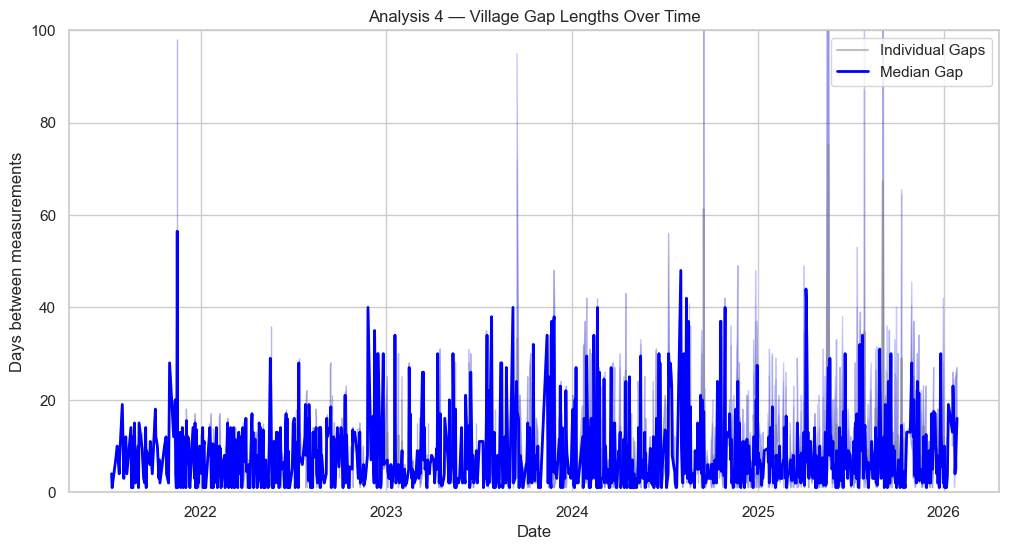

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=gaps_v, x='Date', y='gap_days', alpha=0.5, color='gray', label='Individual Gaps')
sns.lineplot(data=gaps_v, x='Date', y='gap_days', estimator='median', color='blue', linewidth=2, label='Median Gap')
plt.title('Analysis 4 — Village Gap Lengths Over Time')
plt.ylabel('Days between measurements')
plt.ylim(0, 100)
plt.legend()
plt.show()

## Analysis 5 — Proportion of Villages Meeting Measurement Thresholds

/var/folders/1c/f0j4ygyd0jb136rvzr4n3sp00000gp/T/ipykernel_57129/718328149.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'>={t}' for t in thresholds], y=prop_met, palette='magma')


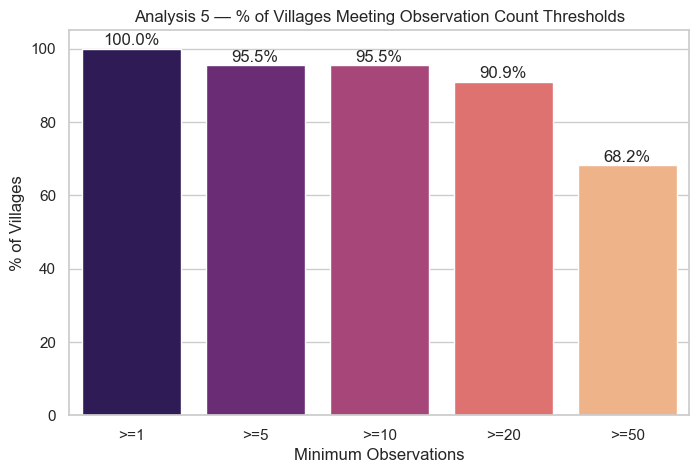

In [8]:
village_counts = morning_village.groupby('inferred_village').size()
thresholds = [1, 5, 10, 20, 50]
prop_met = [(village_counts >= t).mean() * 100 for t in thresholds]

plt.figure(figsize=(8, 5))
sns.barplot(x=[f'>={t}' for t in thresholds], y=prop_met, palette='magma')
plt.title('Analysis 5 — % of Villages Meeting Observation Count Thresholds')
plt.ylabel('% of Villages')
plt.xlabel('Minimum Observations')
for i, v in enumerate(prop_met):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.show()

## Analysis 6 — Gaps by Region (Village Level)

/var/folders/1c/f0j4ygyd0jb136rvzr4n3sp00000gp/T/ipykernel_57129/2770512602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gaps_v, x='region_x', y='gap_days', palette='Set2')


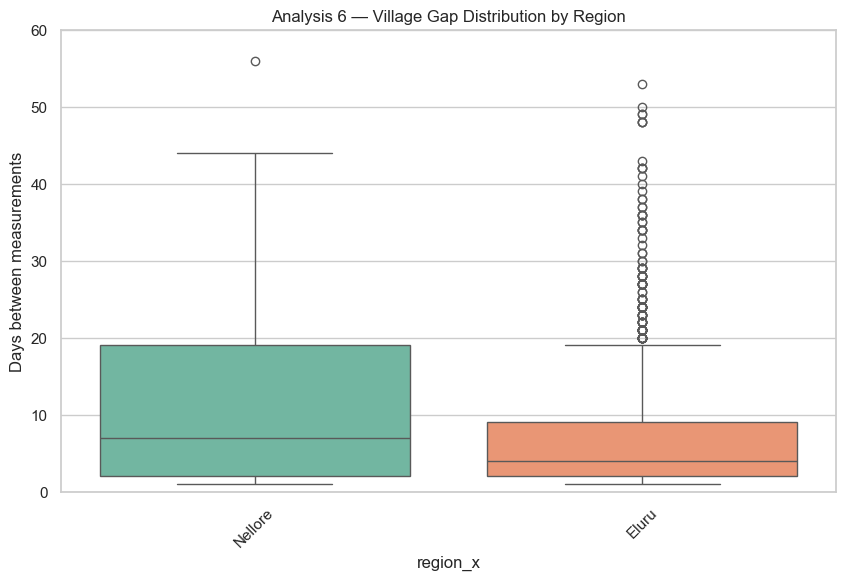

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=gaps_v, x='region_x', y='gap_days', palette='Set2')
plt.title('Analysis 6 — Village Gap Distribution by Region')
plt.ylabel('Days between measurements')
plt.ylim(0, 60)
plt.xticks(rotation=45)
plt.show()

## Analysis 7 — Measurement Frequency vs. Village Sample Size

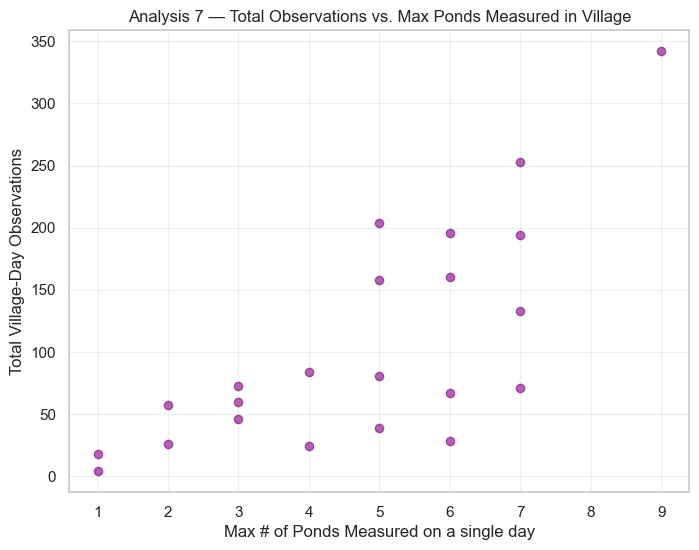

In [10]:
# Sample size here is the number of ponds in the village
village_ponds = morning_village.groupby('inferred_village')['n_ponds'].max()
village_obs = morning_village.groupby('inferred_village').size()

plt.figure(figsize=(8, 6))
plt.scatter(village_ponds, village_obs, alpha=0.6, color='purple')
plt.title('Analysis 7 — Total Observations vs. Max Ponds Measured in Village')
plt.xlabel('Max # of Ponds Measured on a single day')
plt.ylabel('Total Village-Day Observations')
plt.grid(True, alpha=0.3)
plt.show()

## Analysis 8 — Distribution of observations per Month per Village

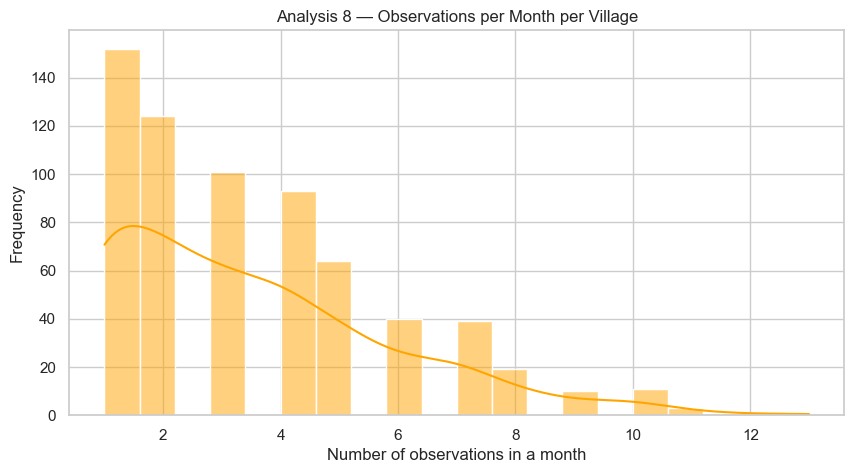

In [11]:
obs_per_month_village = morning_village.groupby(['inferred_village', 'Month']).size()

plt.figure(figsize=(10, 5))
sns.histplot(obs_per_month_village, bins=20, kde=True, color='orange')
plt.title('Analysis 8 — Observations per Month per Village')
plt.xlabel('Number of observations in a month')
plt.ylabel('Frequency')
plt.show()

## Analysis 8b — Measuring true 0 observation months per village

Total village-month combinations since entry: 711
Months with 0 observations: 53 (7.5%)


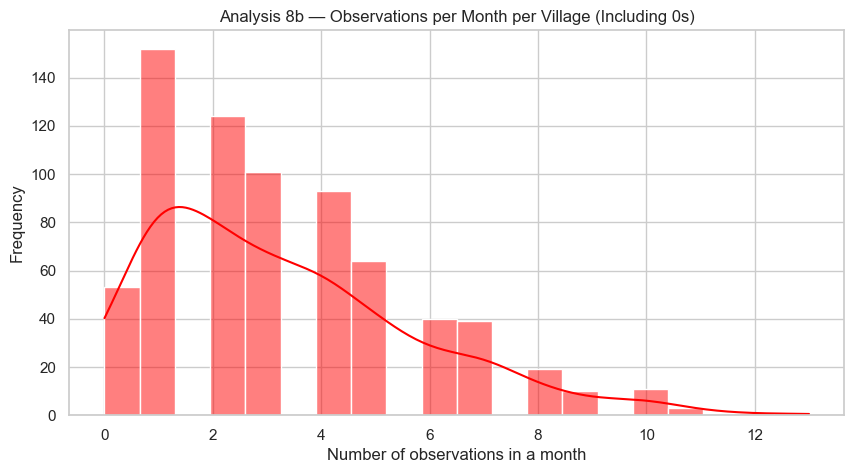

In [12]:
import pandas as pd

# Find entry month and max month overall
village_entry = morning_village.groupby('inferred_village')['Month'].min()
max_month = morning_village['Month'].max()

# Build index of all valid village-month combinations since entry
all_combos = []
for village, start_month in village_entry.items():
    # Use pandas period_range to get all months from start to max_month
    periods = pd.period_range(start=start_month, end=max_month, freq='M')
    for p in periods:
        all_combos.append((village, p))

# Create DataFrame of all combinations
df_full = pd.DataFrame(all_combos, columns=['inferred_village', 'Month'])

# Actual observations per month per village
obs_per_month_village = morning_village.groupby(['inferred_village', 'Month']).size().reset_index(name='obs_count')

# Merge to find zeros
df_merged = pd.merge(df_full, obs_per_month_village, on=['inferred_village', 'Month'], how='left')
df_merged['obs_count'] = df_merged['obs_count'].fillna(0)

# Count and plot
zeros_count = (df_merged['obs_count'] == 0).sum()
total_months = len(df_merged)
print(f"Total village-month combinations since entry: {total_months}")
print(f"Months with 0 observations: {zeros_count} ({(zeros_count/total_months)*100:.1f}%)")

plt.figure(figsize=(10, 5))
sns.histplot(df_merged['obs_count'], bins=20, kde=True, color='red')
plt.title('Analysis 8b — Observations per Month per Village (Including 0s)')
plt.xlabel('Number of observations in a month')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Raw frequency table for the histogram data
hist_table = df_merged['obs_count'].value_counts().sort_index().reset_index()
hist_table.columns = ['Observations per Month', 'Frequency (Village-Months)']
hist_table['Percentage'] = (hist_table['Frequency (Village-Months)'] / hist_table['Frequency (Village-Months)'].sum() * 100).round(2)
print("Raw data for Observations per Month per Village (Analysis 8b):")
display(hist_table)

Raw data for Observations per Month per Village (Analysis 8b):


,Observations per Month,Frequency (Village-Months),Percentage
0,0.0,53,7.45
1,1.0,152,21.38
2,2.0,124,17.44
3,3.0,101,14.21
4,4.0,93,13.08
5,5.0,64,9.00
6,6.0,40,5.63
7,7.0,39,5.49
8,8.0,19,2.67
9,9.0,10,1.41


## Analysis 9 — Seasonal Trends in Village Gaps

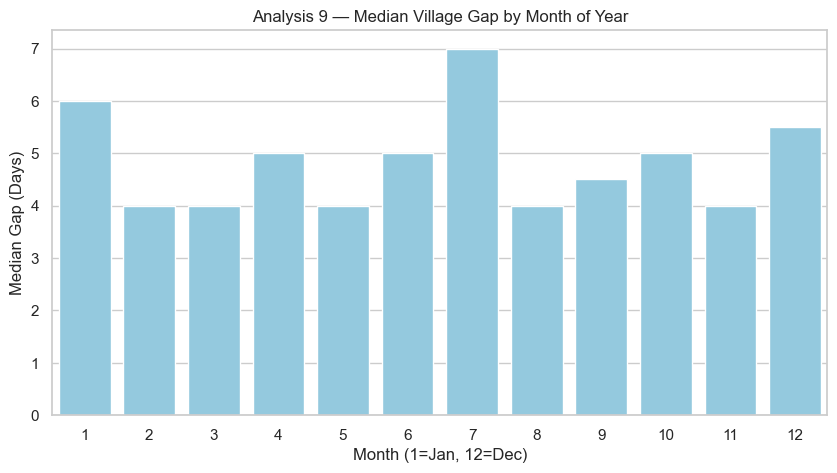

In [14]:
morning_village['MonthNum'] = morning_village['Date'].dt.month
monthly_gaps_v = morning_village.groupby('MonthNum')['gap_days'].median()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_gaps_v.index, y=monthly_gaps_v.values, color='skyblue')
plt.title('Analysis 9 — Median Village Gap by Month of Year')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Median Gap (Days)')
plt.show()

## Analysis 10 — Village Tenure (Active Span) and Observation Density

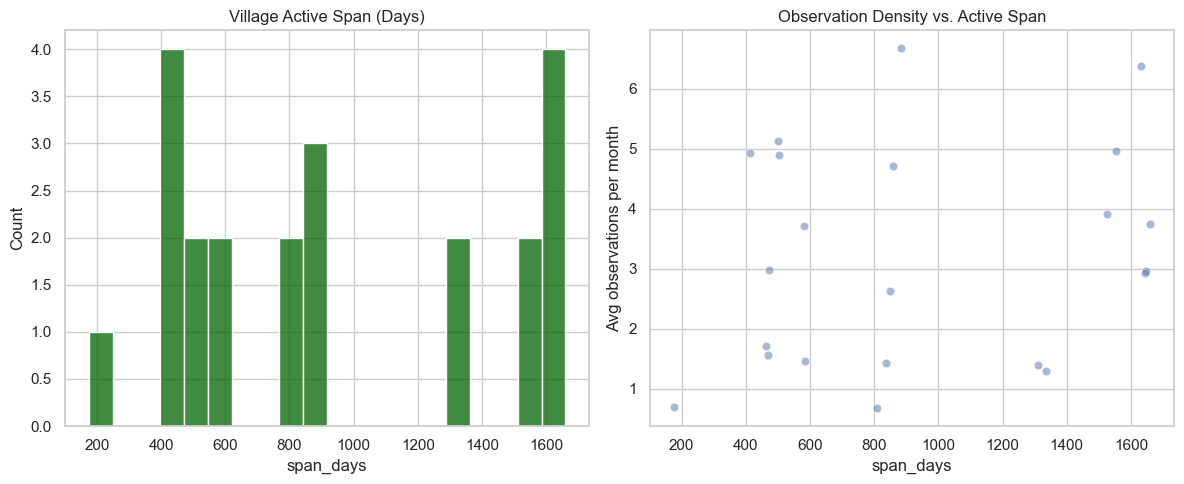

In [15]:
village_tenure = morning_village.groupby('inferred_village')['Date'].agg(['min', 'max', 'count'])
village_tenure['span_days'] = (village_tenure['max'] - village_tenure['min']).dt.days
village_tenure['density'] = village_tenure['count'] / (village_tenure['span_days'] / 30.44) # obs per month

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(village_tenure['span_days'], bins=20, color='darkgreen')
plt.title('Village Active Span (Days)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=village_tenure, x='span_days', y='density', alpha=0.5)
plt.title('Observation Density vs. Active Span')
plt.ylabel('Avg observations per month')
plt.tight_layout()
plt.show()

## Analysis 11 — Longest Consecutive Gap per Village

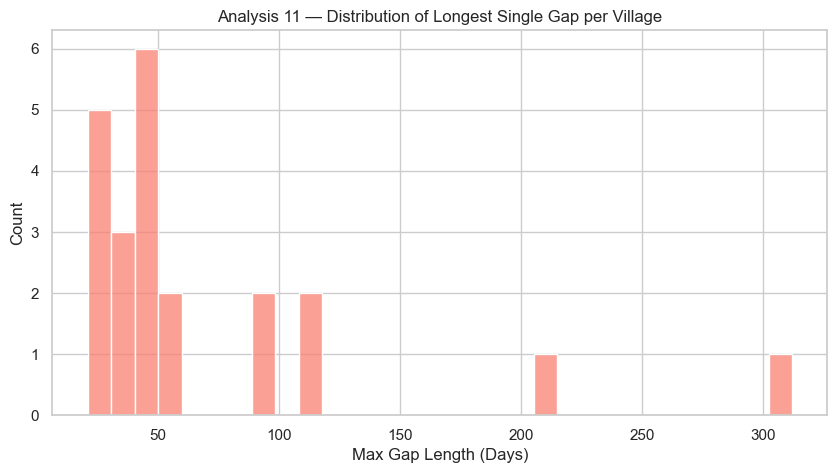

In [16]:
max_gaps_v = gaps_v.groupby('inferred_village')['gap_days'].max()

plt.figure(figsize=(10, 5))
sns.histplot(max_gaps_v, bins=30, color='salmon')
plt.title('Analysis 11 — Distribution of Longest Single Gap per Village')
plt.xlabel('Max Gap Length (Days)')
plt.show()

## Analysis 12 — When Do Villages Enter the Dataset?

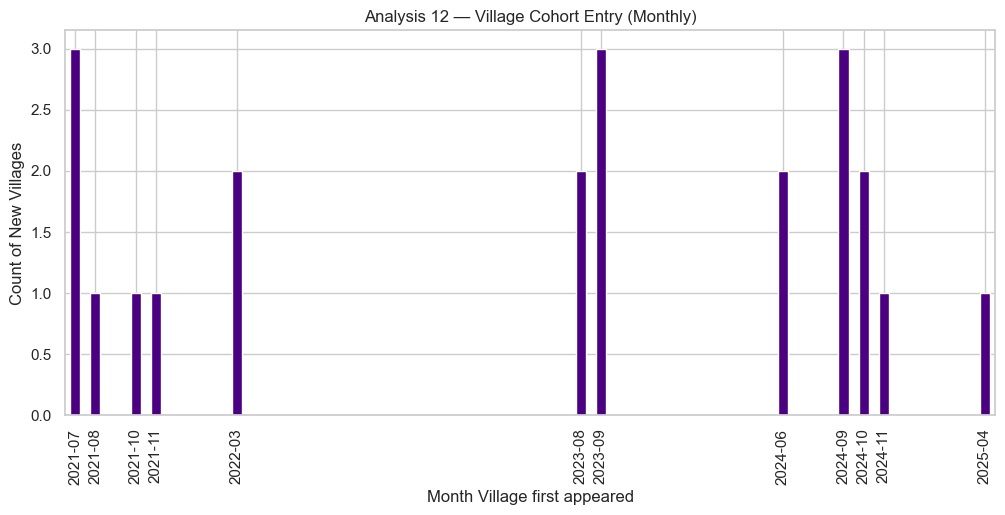

In [17]:
entry_dates_v = morning_village.groupby('inferred_village')['Date'].min().sort_values()
entry_counts_v = entry_dates_v.dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12, 5))
entry_counts_v.plot(kind='bar', color='indigo')
plt.title('Analysis 12 — Village Cohort Entry (Monthly)')
plt.xlabel('Month Village first appeared')
plt.ylabel('Count of New Villages')
plt.show()

## Analysis 13 — Regularity Variation by Quarter

/var/folders/1c/f0j4ygyd0jb136rvzr4n3sp00000gp/T/ipykernel_57129/301130673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=quarterly_cv_v.reset_index(), x='Quarter', y='gap_days', palette='Pastel1')


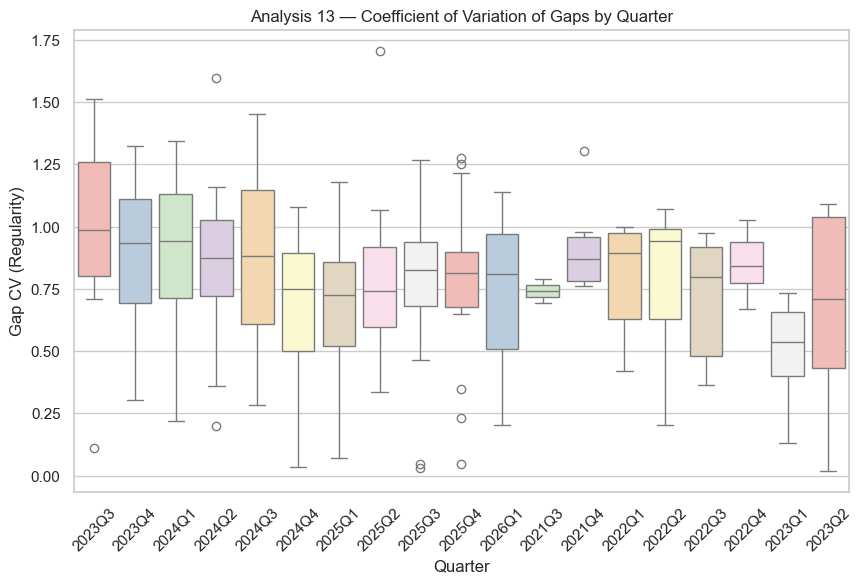

In [18]:
morning_village['Quarter'] = morning_village['Date'].dt.to_period('Q')
quarterly_cv_v = morning_village.groupby(['inferred_village', 'Quarter'])['gap_days'].agg(lambda x: x.std()/x.mean() if x.mean()>0 else np.nan)

plt.figure(figsize=(10, 6))
sns.boxplot(data=quarterly_cv_v.reset_index(), x='Quarter', y='gap_days', palette='Pastel1')
plt.title('Analysis 13 — Coefficient of Variation of Gaps by Quarter')
plt.ylabel('Gap CV (Regularity)')
plt.xticks(rotation=45)
plt.show()

## Analysis 14 — Cumulative Observations for Top Villages Over Time

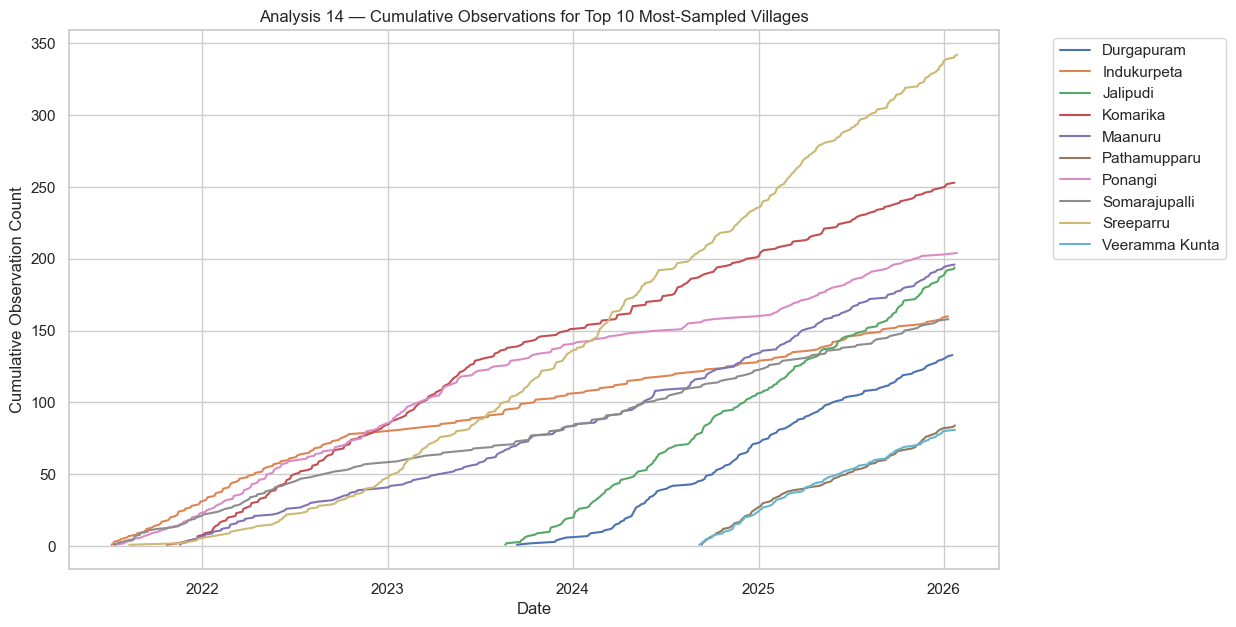

In [19]:
top_villages = village_counts.nlargest(10).index
top_v_data = morning_village[morning_village['inferred_village'].isin(top_villages)].copy()
top_v_data = top_v_data.sort_values(['inferred_village', 'Date'])
top_v_data['cum_obs'] = top_v_data.groupby('inferred_village').cumcount() + 1

plt.figure(figsize=(12, 7))
sns.lineplot(data=top_v_data, x='Date', y='cum_obs', hue='inferred_village')
plt.title('Analysis 14 — Cumulative Observations for Top 10 Most-Sampled Villages')
plt.ylabel('Cumulative Observation Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Analysis 15 — Month-over-Month Village Retention

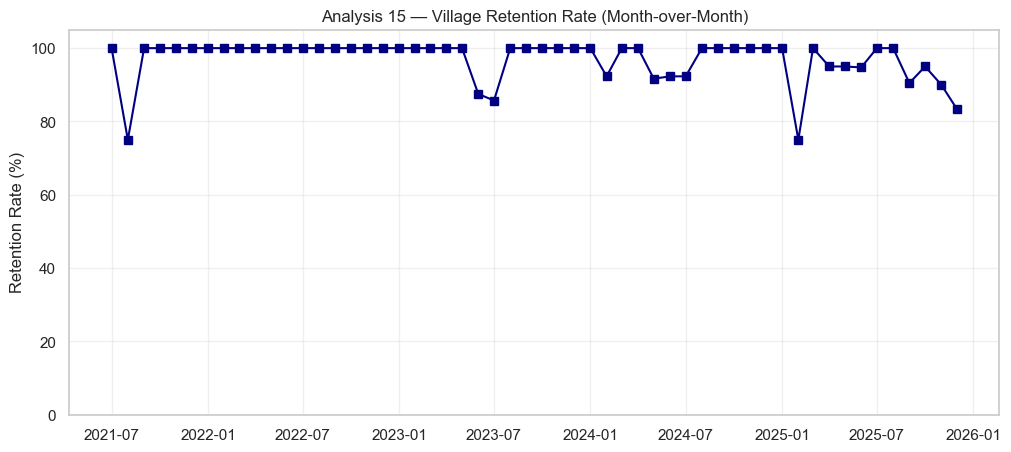

In [20]:
month_villages = morning_village.groupby('Month')['inferred_village'].apply(set)
sorted_months = sorted(month_villages.index)

retention_rows = []
for i in range(len(sorted_months) - 1):
    m0, m1 = sorted_months[i], sorted_months[i + 1]
    s0, s1 = month_villages[m0], month_villages[m1]
    if (m1.start_time - m0.start_time).days < 35: # consecutive months
        retained = len(s0 & s1)
        retention_rows.append({
            'month': m0.to_timestamp(),
            'n_villages': len(s0),
            'retention_rate': (retained / len(s0)) * 100 if len(s0)>0 else 0
        })

df_retention = pd.DataFrame(retention_rows)

plt.figure(figsize=(12, 5))
plt.plot(df_retention['month'], df_retention['retention_rate'], marker='s', color='navy')
plt.title('Analysis 15 — Village Retention Rate (Month-over-Month)')
plt.ylabel('Retention Rate (%)')
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.show()